
Dataset Loaded Successfully

First 5 Records
   Transaction ID        Date User ID           Book Title      Genre  \
0               1  2025-10-16   U1029         Harry Potter    History   
1               2  2024-08-16   U1036     Data Science 101      Novel   
2               3  2025-07-12   U1023               Ikigai  Education   
3               4  2024-01-31   U1024        Python Basics    Science   
4               5  2025-09-08   U1007  Think and Grow Rich    Science   

   Borrowing Duration (Days)  
0                        8.0  
1                       22.0  
2                        2.0  
3                       17.0  
4                        NaN  

Dataset Shape : (500, 6)

Columns
Index(['Transaction ID', 'Date', 'User ID', 'Book Title', 'Genre',
       'Borrowing Duration (Days)'],
      dtype='object')

Missing Values
Transaction ID                0
Date                          0
User ID                       0
Book Title                    8
Genre                   

Enter Choice :  1
Enter Genre :  History


     Transaction ID       Date User ID           Book Title    Genre  \
0                 1 2025-10-16   U1029         Harry Potter  History   
7                 8 2024-06-12   U1109    Rich Dad Poor Dad  History   
11               12 2024-05-07   U1097        Atomic Habits  History   
23               24 2025-10-20   U1118        The Alchemist  History   
24               25 2024-09-09   U1144  Think and Grow Rich  History   
29               30 2025-01-25   U1120  Think and Grow Rich  History   
30               31 2024-01-12   U1030           The Hobbit  History   
31               32 2025-10-18   U1088        Atomic Habits  History   
32               33 2024-06-10   U1117         Harry Potter  History   
59               60 2025-01-23   U1001                 1984  History   
69               70 2024-09-28   U1102        The Alchemist  History   
73               74 2024-03-11   U1063    Rich Dad Poor Dad  History   
74               75 2025-03-24   U1140     Data Science 101  His

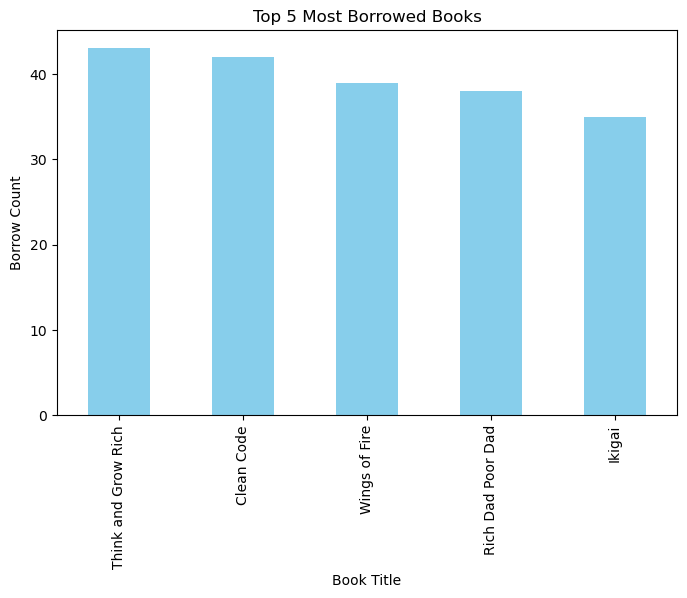

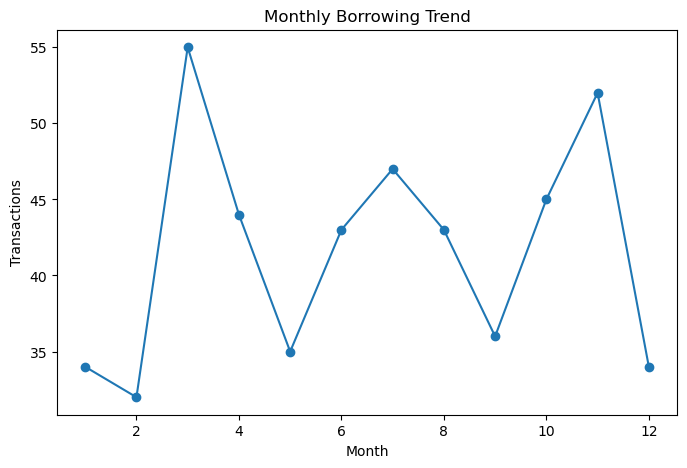

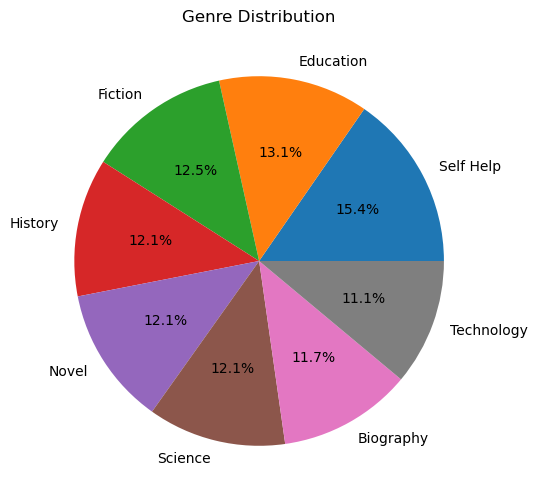

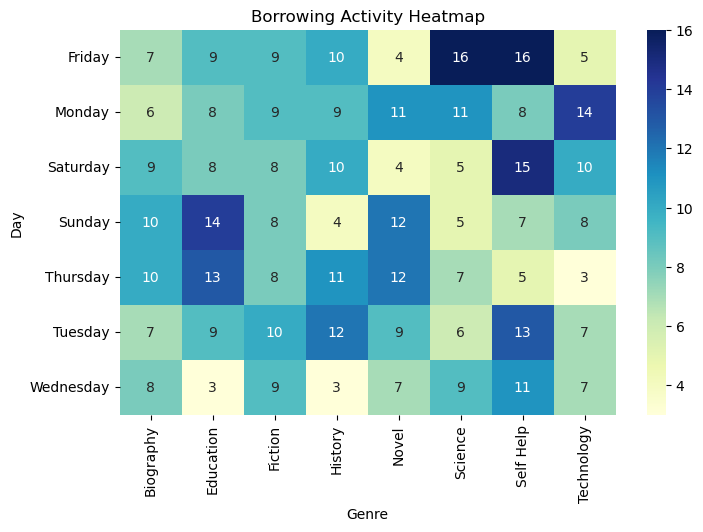

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


class LibraryDashboard:

    def __init__(self):
        self.df = None

    def load_data(self, file_path):

        if not file_path.endswith(".csv"):
            print("Please select a CSV file.")
            return

        self.df = pd.read_csv(file_path)

        print("\nDataset Loaded Successfully\n")

        print("First 5 Records")
        print(self.df.head())

        print("\nDataset Shape :", self.df.shape)

        print("\nColumns")
        print(self.df.columns)

        print("\nMissing Values")
        print(self.df.isnull().sum())

    def calculate_statistics(self):

        print("Most Borrowed Book:")
        print(self.df["Book Title"].value_counts().head(1))

        duration = np.array(self.df["Borrowing Duration (Days)"])

        print("Average :", np.mean(duration))
        print("Maximum :", np.max(duration))
        print("Minimum :", np.min(duration))
        print("Standard Deviation :", np.std(duration))

        self.df["Date"] = pd.to_datetime(self.df["Date"])

        print("Busiest Day :")
        print(self.df["Date"].dt.day_name().value_counts().head(1))

    def filter_transactions(self):

        print("\nFilter Options")
        print("1. Genre")
        print("2. Borrowing Duration")
        
        choice = int(input("Enter Choice : "))
        
        if choice == 1:
            genre = input("Enter Genre : ")
            print(self.df[self.df["Genre"] == genre])
        
        elif choice == 2:
            days = int(input("Enter Minimum Borrowing Days : "))
            print(self.df[self.df["Borrowing Duration (Days)"] >= days])
        
        else:
            print("Invalid Choice")


    def generate_report(self):

        print("\n========== LIBRARY REPORT ==========")

        print("\nTotal Transactions :", len(self.df))

        print("\nTotal Books :", self.df["Book Title"].nunique())

        print("\nTotal Users :", self.df["User ID"].nunique())

        print("\nAverage Borrowing Duration :",
          round(self.df["Borrowing Duration (Days)"].mean(), 2))

        print("\nMost Borrowed Book :")
        print(self.df["Book Title"].value_counts().head(1))

        print("\nGenre Distribution :")
        print(self.df["Genre"].value_counts())

        print("\n===================================")

    
    def visualize_data(self):
        
        self.df["Date"] = pd.to_datetime(self.df["Date"])
        plt.figure(figsize=(8,5))
        self.df["Book Title"].value_counts().head(5).plot(kind="bar", color="skyblue")
        plt.title("Top 5 Most Borrowed Books")
        plt.xlabel("Book Title")
        plt.ylabel("Borrow Count")
        plt.show()

    
        plt.figure(figsize=(8,5))
        monthly = self.df.groupby(self.df["Date"].dt.month)["Transaction ID"].count()
        monthly.plot(marker="o")
        plt.title("Monthly Borrowing Trend")
        plt.xlabel("Month")
        plt.ylabel("Transactions")
        plt.show()

    
        plt.figure(figsize=(6,6))
        self.df["Genre"].value_counts().plot(kind="pie", autopct="%1.1f%%")
        plt.title("Genre Distribution")
        plt.ylabel("")
        plt.show()

    
        self.df["Day"] = self.df["Date"].dt.day_name()

        heat = pd.crosstab(
        self.df["Day"],
        self.df["Genre"]
    )

        plt.figure(figsize=(8,5))
        sns.heatmap(heat, annot=True, cmap="YlGnBu")
        plt.title("Borrowing Activity Heatmap")
        plt.show()


library = LibraryDashboard()

library.load_data(r"C:\Users\rnw\Downloads\library_transactions_500.csv")

library.calculate_statistics()

library.filter_transactions()

library.generate_report()

library.visualize_data()